# Tarea 1: Reflexión epistemológica
### Libreta 00: Modelos, Metáforas y la Naturaleza

**Fenómeno elegido: el forrajeo bacteriano (quimiotaxis de *Escherichia coli*)**

> Respondo las cuatro preguntas de la tarea con argumentos conceptuales y cierro
> con una figura que compara el fenómeno con el descenso de gradiente (pregunta 4).


## 1. El fenómeno natural

*E. coli* es una bacteria de pocos micrómetros que se desplaza en un medio líquido
hacia los nutrientes y lejos de las sustancias nocivas. Alterna **dos modos** de
locomoción según el sentido de giro de sus flagelos:

- **Nado (*run*):** los flagelos giran coordinados y forman un haz que impulsa a la
  bacteria en línea casi recta.
- **Tumbo (*tumble*):** el haz se deshace, la bacteria gira sobre sí misma sin
  avanzar y queda apuntando en una dirección al azar.

La bacteria es demasiado pequeña para medir el gradiente de concentración en el
*espacio*, así que compara **en el tiempo**: si mientras nada detecta que el
nutriente aumenta, prolonga el nado; si detecta que baja, tumba antes y prueba
otra dirección. De esa regla surge un **paseo aleatorio sesgado** (*biased random
walk*) hacia las regiones ricas.

En la **colonia** se suman tres mecanismos que el algoritmo *Bacterial Foraging
Optimization* convierte en operadores:

1. **Quimiotaxis:** el ciclo nado/tumbo anterior.
2. **Reproducción:** las bacterias mejor alimentadas se dividen y las peores
   mueren, una forma de selección.
3. **Dispersión y eliminación:** las corrientes o el agotamiento del medio
   reubican bacterias al azar y evitan que la población se estanque en una región.

El fenómeno inspira un algoritmo de optimización: la colonia localiza zonas ricas
sin ningún modelo del entorno, igual que un optimizador busca el mínimo de una
función. Maximizar nutriente equivale a minimizar una función objetivo.


## 2. Metáfora vs. modelo operativo

No todo en la analogía pasa al algoritmo. Conviene separar el **recurso narrativo**
del **mecanismo computacional**:

| Aspecto del fenómeno | Metáfora (no se formaliza) | Modelo operativo (formalizable) |
|---|---|---|
| "Buscar comida", "querer sobrevivir" | La *intención* o *voluntad* de la bacteria | Una función objetivo $f(\mathbf{x})$ a optimizar (concentración de nutriente) |
| "Sentir" el medio | La experiencia sensorial | Evaluar $f$ en la posición actual $\mathbf{x}$ |
| Nado (*run*) | El "esfuerzo" por avanzar | Un paso $\mathbf{x}' = \mathbf{x} + C\,\hat{\mathbf{d}}$ de longitud $C$ en dirección unitaria $\hat{\mathbf{d}}$ |
| Decisión de tumbar | El "instinto" de cambiar de rumbo | Regla: si $f(\mathbf{x}')$ mejora, repetir dirección; si no, muestrear $\hat{\mathbf{d}}$ nueva al azar |
| Reproducción | La "lucha por la vida" | Selección elitista: duplicar las mejores soluciones, descartar las peores |
| Dispersión | El "azar del ambiente" | Reinicio aleatorio de una fracción de la población |
| *Swarming* (atracción entre células) | La "cooperación" | Un término aditivo de atracción/repulsión sobre $f$ |

La **voluntad** de la bacteria es metáfora pura. El algoritmo formaliza otra cosa:
el **paseo aleatorio sesgado por comparación temporal** del valor de $f$, más una
capa de selección y reinicio sobre la población.


## 3. De la heurística al principio metaheurístico

El **principio** del fenómeno es una heurística local simple:

> *Avanza mientras la situación mejore; si deja de mejorar, reorienta al azar.*

Es una heurística de bajo nivel (codiciosa más perturbación aleatoria),
específica de "moverse por un medio". Para volverla una **metaheurística de alto
nivel**, independiente del problema, se la envuelve en una estructura de control
que coordina **exploración** y **explotación**. Ese es el diseño de la *Bacterial
Foraging Optimization* (Passino, 2002): tres bucles anidados sobre una población
de soluciones.

```text
inicializar población de S "bacterias" en posiciones aleatorias
repetir (eliminación–dispersión):          # diversificación global
    repetir (reproducción):                # presión selectiva
        repetir (quimiotaxis):             # búsqueda local
            para cada bacteria:
                tumbo: elegir dirección unitaria aleatoria d
                nado:  mientras f mejore y no se exceda Ns pasos:
                           avanzar un paso de tamaño C en dirección d
        ordenar bacterias por salud (suma de f a lo largo de su vida)
        duplicar la mejor mitad, eliminar la peor mitad
    dispersar al azar una fracción de bacterias a nuevas posiciones
```

Cada bucle aporta un ingrediente del balance clásico:

- **Quimiotaxis (nado/tumbo):** explotación local y escape mediante tumbos.
- **Reproducción:** intensifica las regiones prometedoras (explotación global).
- **Eliminación–dispersión:** inyecta diversidad para no quedar atrapado
  (exploración global).

Así, "mejora local más aleatoriedad estructurada" pasa de truco para "moverse" a
estrategia de búsqueda aplicable a cualquier $f$ evaluable.


## 4. Comparación con el descenso de gradiente

**En qué se parecen**

- Los dos son métodos iterativos de mejora: parten de un punto y lo desplazan
  buscando reducir la función objetivo.
- Los dos, en lo local, intentan moverse cuesta abajo.
- En un paisaje suave y unimodal, con pasos pequeños, ambos convergen a la misma
  región.

**En qué difieren**

| Criterio | Descenso de gradiente | Forrajeo bacteriano (quimiotaxis) |
|---|---|---|
| Información que usa | El **gradiente** $\nabla f$ (analítico o numérico) | El **signo del cambio** de $f$ entre dos evaluaciones consecutivas |
| Dirección de avance | La de **máximo descenso**, exacta | Una dirección **aleatoria**, aceptada o rechazada según mejore |
| Requisito sobre $f$ | $f$ **diferenciable** y continua | Solo poder **evaluar** $f$ (sirve no diferenciable, discreta, ruidosa) |
| Óptimos locales | Se **atasca** en el primero que encuentra | **Escapa** por tumbos y dispersión (es estocástico) |
| Nº de candidatos | **Uno** | Una **población** que explora en paralelo |
| Naturaleza | Determinista | Estocástica |

La diferencia de fondo es epistemológica. El descenso de gradiente supone que
conocemos la pendiente del paisaje, es decir, que es suave y derivable. El
forrajeo bacteriano no supone nada sobre el paisaje, solo que podemos probarlo
punto a punto. Por eso resiste donde el gradiente falla: en paisajes
multimodales, no diferenciables o de "caja negra". La figura lo muestra sobre la
función de Rastrigin (2D), un paisaje multimodal clásico.


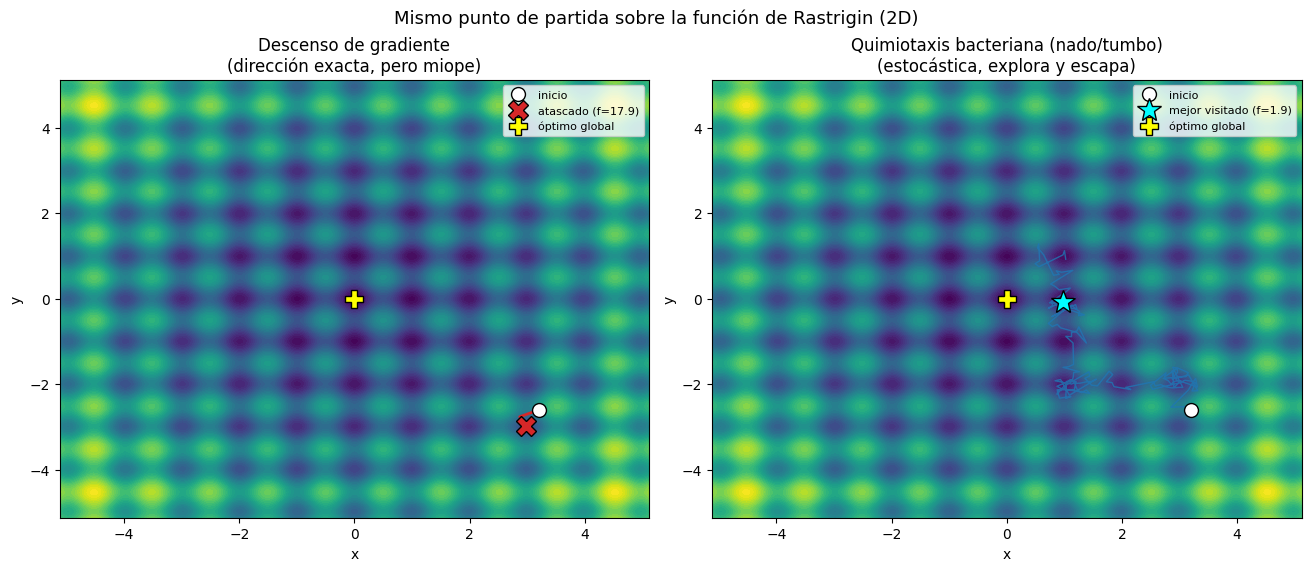

Inicio:                       [ 3.2 -2.6],  f = 42.000
Gradiente   -> punto final:   [ 2.985 -2.985],  f = 17.909  (atascado en mínimo local)
Quimiotaxis -> mejor punto:   [ 0.977 -0.065],  f = 1.891  (mucho más cerca del global)
Óptimo global en (0, 0), f = 0.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Paisaje multimodal: Rastrigin 2D (mínimo global en (0,0), f=0) ---
def rastrigin(x, y, A=10):
    return 2 * A + (x**2 - A * np.cos(2 * np.pi * x)) + (y**2 - A * np.cos(2 * np.pi * y))

def grad_rastrigin(p, A=10):
    x, y = p
    gx = 2 * x + 2 * np.pi * A * np.sin(2 * np.pi * x)
    gy = 2 * y + 2 * np.pi * A * np.sin(2 * np.pi * y)
    return np.array([gx, gy])

# --- (a) Descenso de gradiente: usa la pendiente exacta, se atasca en un local ---
def gradient_descent(p0, lr=0.005, steps=200):
    p = np.array(p0, float)
    traj = [p.copy()]
    for _ in range(steps):
        p = p - lr * grad_rastrigin(p)
        traj.append(p.copy())
    return np.array(traj)

# --- (b) Quimiotaxis bacteriana fiel a BFO (Passino, 2002) ---
# El TUMBO da un paso incondicional en una dirección aleatoria (puede empeorar:
# ese es el mecanismo de escape); el NADO continúa solo mientras se siga mejorando.
# Un optimizador retiene el MEJOR punto visitado a lo largo del paseo.
def chemotaxis(p0, seed=6, C=0.1, Ns=4, n_steps=150):
    rng = np.random.default_rng(seed)
    p = np.array(p0, float)
    f_cur = rastrigin(*p)
    traj = [p.copy()]
    best_p, best_f = p.copy(), f_cur
    for _ in range(n_steps):
        d = rng.normal(size=2)
        d /= np.linalg.norm(d)            # dirección aleatoria unitaria
        p = p + C * d                     # TUMBO: paso incondicional
        f_new = rastrigin(*p)
        traj.append(p.copy())
        if f_new < best_f: best_f, best_p = f_new, p.copy()
        m = 0
        while m < Ns and f_new < f_cur:   # NADO: continuar mientras mejore
            f_cur = f_new
            p = p + C * d
            f_new = rastrigin(*p)
            traj.append(p.copy())
            if f_new < best_f: best_f, best_p = f_new, p.copy()
            m += 1
        f_cur = f_new
    return np.array(traj), best_p, best_f

start = np.array([3.2, -2.6])  # mismo punto de partida para ambos
gd = gradient_descent(start)
ch, ch_best_p, ch_best_f = chemotaxis(start)

# --- Malla del paisaje ---
g = np.linspace(-5.12, 5.12, 400)
X, Y = np.meshgrid(g, g)
Z = rastrigin(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), constrained_layout=True)

# Panel izquierdo: gradiente
ax = axes[0]
ax.contourf(X, Y, Z, levels=40, cmap="viridis")
ax.plot(gd[:, 0], gd[:, 1], "-", color="tab:red", lw=2.0)
ax.plot(*start, "o", color="white", mec="black", ms=10, label="inicio")
ax.plot(gd[-1, 0], gd[-1, 1], "X", color="tab:red", mec="black", ms=14,
        label=f"atascado (f={rastrigin(*gd[-1]):.1f})")
ax.plot(0, 0, "P", color="yellow", mec="black", ms=13, label="óptimo global")
ax.set_title("Descenso de gradiente\n(dirección exacta, pero miope)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="upper right", fontsize=8)

# Panel derecho: quimiotaxis
ax = axes[1]
ax.contourf(X, Y, Z, levels=40, cmap="viridis")
ax.plot(ch[:, 0], ch[:, 1], "-", color="tab:blue", lw=1.0, alpha=0.8)
ax.plot(*start, "o", color="white", mec="black", ms=10, label="inicio")
ax.plot(ch_best_p[0], ch_best_p[1], "*", color="cyan", mec="black", ms=18,
        label=f"mejor visitado (f={ch_best_f:.1f})")
ax.plot(0, 0, "P", color="yellow", mec="black", ms=13, label="óptimo global")
ax.set_title("Quimiotaxis bacteriana (nado/tumbo)\n(estocástica, explora y escapa)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Mismo punto de partida sobre la función de Rastrigin (2D)", fontsize=13)
plt.show()

print(f"Inicio:                       {start},  f = {rastrigin(*start):.3f}")
print(f"Gradiente   -> punto final:   {gd[-1].round(3)},  f = {rastrigin(*gd[-1]):.3f}  (atascado en mínimo local)")
print(f"Quimiotaxis -> mejor punto:   {ch_best_p.round(3)},  f = {ch_best_f:.3f}  (mucho más cerca del global)")
print("Óptimo global en (0, 0), f = 0.0")


### Lectura de la figura

Desde el **mismo punto** $(3.2, -2.6)$, el descenso de gradiente cae al **mínimo
local más cercano** $(3, -3)$ y se queda ahí ($f \approx 17.9$): su dirección es
exacta, pero su horizonte es local. La quimiotaxis avanza a tirones (el tumbo da
un paso aunque empeore, y solo nada mientras siga mejorando) y ese paseo
aleatorio sesgado le permite atravesar barreras del paisaje y llegar a una región
mejor, cercana al óptimo global ($f \approx 1.9$). Un método sabe hacia dónde
bajar; el otro explora sin un mapa.

> El valor numérico depende de la semilla aleatoria (aquí fijada para
> reproducibilidad); la figura ilustra el comportamiento cualitativo: dirección
> exacta pero miope en el gradiente, búsqueda estocástica capaz de escapar de
> óptimos locales en la bacteria. El gradiente necesita la derivada $\nabla f$; la
> bacteria solo evalúa $f$.

## Conclusión

El forrajeo bacteriano optimiza con una **regla local mínima** (avanzar mientras
se mejore, reorientar al azar cuando no) y **aleatoriedad estructurada** sobre la
población. Le basta para encontrar buenas soluciones en paisajes que el descenso
de gradiente no aborda: sin derivadas, sin un modelo del entorno y sin suponer que
el paisaje sea "bien comportado". Ahí está la justificación epistemológica de las
metaheurísticas inspiradas en la naturaleza. Quien las diseña no reproduce el
detalle biológico; toma su estructura funcional (exploración, explotación,
adaptación) y la usa como método de búsqueda general.
